# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Aldini Dziaul Haq]
- **Email:** [aldy5929@gmail.com]
- **ID Dicoding:** [aldini_dziaul_haq]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren jumlah order dan total revenue Olist secara bulanan sepanjang tahun 2017-2018, dan pada bulan apa penjualan mencapai puncaknya?
- **Pertanyaan 2:** Kategori produk apa yang memiliki rata-rata review score terendah sepanjang 2017-2018, dan berapa persentase order dengan score ≤ 2 pada kategori tersebut?
- **Pertanyaan 3:** Bagaimana segmentasi pelanggan Olist berdasarkan perilaku pembelian (Recency, Frequency, Monetary) sepanjang 2017-2018?
- **Pertanyaan 4:** Negara bagian (state) mana di Brazil yang menghasilkan jumlah order dan revenue tertinggi sepanjang 2017-2018?

## Import Semua Packages/Library yang Digunakan

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

#### Load df ...

In [16]:
# Load semua dataset
customers_df   = pd.read_csv('/content/customers_dataset.csv')
orders_df      = pd.read_csv('/content/orders_dataset.csv')
order_items_df = pd.read_csv('/content/order_items_dataset.csv')
payments_df    = pd.read_csv('/content/order_payments_dataset.csv')
reviews_df     = pd.read_csv('/content/order_reviews_dataset.csv')
products_df    = pd.read_csv('/content/products_dataset.csv')
sellers_df     = pd.read_csv('/content/sellers_dataset.csv')
geo_df         = pd.read_csv('/content/geolocation_dataset.csv')
category_df    = pd.read_csv('/content/product_category_name_translation.csv')

# Cek shape masing-masing
for name, df in {
    'customers'   : customers_df,
    'orders'      : orders_df,
    'order_items' : order_items_df,
    'payments'    : payments_df,
    'reviews'     : reviews_df,
    'products'    : products_df,
    'sellers'     : sellers_df,
    'geolocation' : geo_df,
    'category'    : category_df
}.items():
    print(f"✅ {name:20s} → {df.shape[0]:,} baris, {df.shape[1]} kolom")

✅ customers            → 99,441 baris, 5 kolom
✅ orders               → 99,441 baris, 8 kolom
✅ order_items          → 112,650 baris, 7 kolom
✅ payments             → 103,886 baris, 5 kolom
✅ reviews              → 99,224 baris, 7 kolom
✅ products             → 32,951 baris, 9 kolom
✅ sellers              → 3,095 baris, 4 kolom
✅ geolocation          → 1,000,163 baris, 5 kolom
✅ category             → 71 baris, 2 kolom


**Insight:** (Opsional)
- Dataset terdiri dari 9 file CSV yang saling berhubungan seperti skema relasional database
- Dataset terbesar adalah orders dan order_items yang menjadi tabel utama analisis
- Semua file berhasil dimuat tanpa error

### Assessing Data

#### Identifying ... problem

In [17]:
# ============================================================
# ASSESSING DATA
# ============================================================

# 1. Cek Missing Values
print("=" * 55)
print("📌 MISSING VALUES")
print("=" * 55)
for name, df in {
    'customers'   : customers_df,
    'orders'      : orders_df,
    'order_items' : order_items_df,
    'payments'    : payments_df,
    'reviews'     : reviews_df,
    'products'    : products_df,
    'sellers'     : sellers_df,
    'geolocation' : geo_df,
    'category'    : category_df
}.items():
    missing = df.isnull().sum().sum()
    print(f"{'🔴' if missing > 0 else '🟢'} {name:20s} → {missing} missing values")

# 2. Cek Duplicate Data
print("\n" + "=" * 55)
print("📌 DUPLICATE DATA")
print("=" * 55)
for name, df in {
    'customers'   : customers_df,
    'orders'      : orders_df,
    'order_items' : order_items_df,
    'payments'    : payments_df,
    'reviews'     : reviews_df,
    'products'    : products_df,
    'sellers'     : sellers_df,
    'geolocation' : geo_df,
    'category'    : category_df
}.items():
    dup = df.duplicated().sum()
    print(f"{'🔴' if dup > 0 else '🟢'} {name:20s} → {dup} duplikat")

# 3. Cek Tipe Data Orders
print("\n" + "=" * 55)
print("📌 TIPE DATA - ORDERS")
print("=" * 55)
print(orders_df.dtypes)

# 4. Cek Outlier Payment Value
print("\n" + "=" * 55)
print("📌 STATISTIK PAYMENT VALUE")
print("=" * 55)
print(payments_df['payment_value'].describe())

📌 MISSING VALUES
🟢 customers            → 0 missing values
🔴 orders               → 4908 missing values
🟢 order_items          → 0 missing values
🟢 payments             → 0 missing values
🔴 reviews              → 145903 missing values
🔴 products             → 2448 missing values
🟢 sellers              → 0 missing values
🟢 geolocation          → 0 missing values
🟢 category             → 0 missing values

📌 DUPLICATE DATA
🟢 customers            → 0 duplikat
🟢 orders               → 0 duplikat
🟢 order_items          → 0 duplikat
🟢 payments             → 0 duplikat
🟢 reviews              → 0 duplikat
🟢 products             → 0 duplikat
🟢 sellers              → 0 duplikat
🔴 geolocation          → 261831 duplikat
🟢 category             → 0 duplikat

📌 TIPE DATA - ORDERS
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_d

**Steps to Take:**
- Konversi kolom tanggal di orders_df dari tipe object → datetime
- Drop atau isi missing values yang ditemukan pada kolom yang relevan



**Insight:** (Opsional)
- Kolom tanggal seperti order_purchase_timestamp masih bertipe object padahal seharusnya datetime
- Terdapat missing values pada beberapa kolom di orders dan reviews yang perlu ditangani sebelum analisis

### Cleaning Data

#### Fixing ... problem

In [18]:
# ============================================================
# CLEANING DATA
# ============================================================

# 1. Convert kolom tanggal ke datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 2. Drop missing values
orders_df.dropna(subset=['order_approved_at', 'order_delivered_customer_date'], inplace=True)
reviews_df.dropna(subset=['review_score'], inplace=True)
products_df.dropna(subset=['product_category_name'], inplace=True)

# 3. Filter hanya status 'delivered'
orders_clean = orders_df[orders_df['order_status'] == 'delivered'].copy()

# 4. Filter tahun 2017-2018
orders_clean = orders_clean[
    orders_clean['order_purchase_timestamp'].dt.year.isin([2017, 2018])
].copy()

# 5. Tambah kolom bantu
orders_clean['year']       = orders_clean['order_purchase_timestamp'].dt.year
orders_clean['month']      = orders_clean['order_purchase_timestamp'].dt.month
orders_clean['year_month'] = orders_clean['order_purchase_timestamp'].dt.to_period('M')

# 6. Merge semua dataset
df_main = (orders_clean
    .merge(customers_df,   on='customer_id',          how='left')
    .merge(payments_df,    on='order_id',              how='left')
    .merge(order_items_df, on='order_id',              how='left')
    .merge(products_df,    on='product_id',            how='left')
    .merge(category_df,    on='product_category_name', how='left')
    .merge(sellers_df,     on='seller_id',             how='left')
)

print(f"✅ Cleaning selesai!")
print(f"✅ df_main shape: {df_main.shape}")

✅ Cleaning selesai!
✅ df_main shape: (114681, 37)


**Insight:** (Opsional)
- Setelah cleaning, data siap digunakan untuk analisis dengan periode 2017–2018
- Kolom tanggal sudah bertipe datetime sehingga bisa diekstrak tahun, bulan, dan periodenya


##Exploratory Data Analysis (EDA)

###EDA Pertanyaan 1 — Tren Penjualan

In [19]:
# ============================================================
# EDA - PERTANYAAN 1: Tren Penjualan
# ============================================================

# Agregasi per bulan
monthly = (df_main.groupby('year_month', as_index=False)
    .agg(
        total_order   = ('order_id',      'nunique'),
        total_revenue = ('payment_value', 'sum')
    )
    .sort_values('year_month')
)
monthly['year_month_str'] = monthly['year_month'].astype(str)

print("📊 Tren Penjualan Bulanan:")
print(monthly[['year_month_str','total_order','total_revenue']].to_string(index=False))

# Statistik deskriptif
print("\n📊 Statistik Order:")
print(monthly['total_order'].describe())

print("\n📊 Statistik Revenue:")
print(monthly['total_revenue'].describe())

# Puncak penjualan
peak_order   = monthly.loc[monthly['total_order'].idxmax()]
peak_revenue = monthly.loc[monthly['total_revenue'].idxmax()]
print(f"\n🏆 Puncak Order   : {peak_order['year_month_str']} ({peak_order['total_order']:,} order)")
print(f"🏆 Puncak Revenue : {peak_revenue['year_month_str']} (R$ {peak_revenue['total_revenue']:,.2f})")

📊 Tren Penjualan Bulanan:
year_month_str  total_order  total_revenue
       2017-01          748      176376.56
       2017-02         1641      323815.95
       2017-03         2546      505735.83
       2017-04         2303      456108.32
       2017-05         3545      701119.60
       2017-06         3135      585400.98
       2017-07         3872      716069.98
       2017-08         4193      842689.94
       2017-09         4150      996279.59
       2017-10         4478      998609.62
       2017-11         7288     1548547.86
       2017-12         5513     1020067.26
       2018-01         7069     1374064.02
       2018-02         6555     1279970.45
       2018-03         7003     1435458.33
       2018-04         6798     1466607.15
       2018-05         6749     1480667.59
       2018-06         6096     1285396.78
       2018-07         6156     1306707.42
       2018-08         6351     1211240.09

📊 Statistik Order:
count      20.000000
mean     4809.450000
std      

###EDA - PERTANYAAN 2: Kepuasan Pelanggan

In [20]:
# ============================================================
# EDA - PERTANYAAN 2: Kepuasan Pelanggan
# ============================================================

# Merge reviews
df_review = df_main.merge(
    reviews_df[['order_id','review_score']], on='order_id', how='left'
)

# EDA Univariate - distribusi review score
print("📊 Distribusi Review Score:")
print(df_review['review_score'].value_counts().sort_index())

print("\n📊 Statistik Review Score:")
print(df_review['review_score'].describe())

# EDA Kategorikal - agregasi per kategori
cat_review = (df_review
    .groupby('product_category_name_english', as_index=False)
    .agg(
        avg_score     = ('review_score', 'mean'),
        total_order   = ('order_id',     'nunique'),
        low_score_pct = ('review_score', lambda x: (x <= 2).sum() / len(x) * 100)
    )
)
cat_review = cat_review.dropna(subset=['product_category_name_english'])
cat_review = cat_review[cat_review['total_order'] >= 30].sort_values('avg_score')

print("\n📊 Bottom 10 Kategori Review Score Terendah:")
print(cat_review.head(10).to_string(index=False))

📊 Distribusi Review Score:
review_score
1.0    13062
2.0     3885
3.0     9621
4.0    22089
5.0    65848
Name: count, dtype: int64

📊 Statistik Review Score:
count    114505.000000
mean          4.080966
std           1.347192
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review_score, dtype: float64

📊 Bottom 10 Kategori Review Score Terendah:
    product_category_name_english  avg_score  total_order  low_score_pct
                 office_furniture   3.558807         1248      24.302789
            fashion_male_clothing   3.669118          105      27.737226
                  fixed_telephony   3.751969          207      23.346304
                            audio   3.839142          346      21.220159
furniture_mattress_and_upholstery   3.875000           37      17.500000
                   party_supplies   3.911111           38      20.000000
                   bed_bath_table   3.915725         9266      18.4

###EDA - PERTANYAAN 3: RFM Analysis

In [21]:
# ============================================================
# EDA - PERTANYAAN 3: RFM Analysis
# ============================================================

snapshot_date = df_main['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = (df_main.groupby('customer_unique_id', as_index=False)
    .agg(
        recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        frequency = ('order_id',                 'nunique'),
        monetary  = ('payment_value',            'sum')
    )
)

# EDA Numerikal - statistik RFM
print("📊 Statistik RFM:")
print(rfm[['recency','frequency','monetary']].describe())

# Scoring
rfm['r_score'] = pd.qcut(rfm['recency'],   5, labels=[5,4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'],  5, labels=[1,2,3,4,5])

def segment_rfm(row):
    r, f, m = int(row['r_score']), int(row['f_score']), int(row['m_score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['segment'] = rfm.apply(segment_rfm, axis=1)

# EDA Kategorikal - distribusi segmen
print("\n📊 Distribusi Segmen Pelanggan:")
print(rfm['segment'].value_counts())

print("\n📊 Rata-rata RFM per Segmen:")
print(rfm.groupby('segment')[['recency','frequency','monetary']].mean().round(2))

📊 Statistik RFM:
            recency     frequency       monetary
count  93083.000000  93083.000000   93083.000000
mean     236.665664      1.033368     211.756533
std      150.902032      0.209011     642.781456
min        1.000000      1.000000       9.590000
25%      114.000000      1.000000      63.735000
50%      218.000000      1.000000     112.950000
75%      345.000000      1.000000     201.650000
max      602.000000     15.000000  109312.640000

📊 Distribusi Segmen Pelanggan:
segment
Loyal Customers    27322
Lost Customers     22252
At Risk            22066
New Customers      14981
Champions           6462
Name: count, dtype: int64

📊 Rata-rata RFM per Segmen:
                 recency  frequency  monetary
segment                                      
At Risk           392.56       1.05    212.00
Champions          91.03       1.18    441.92
Lost Customers    336.05       1.00    206.21
Loyal Customers   144.20       1.03    165.70
New Customers      90.89       1.00    204.36


###EDA - PERTANYAAN 4: Geospatial

In [22]:
# ============================================================
# EDA - PERTANYAAN 4: Geospatial
# ============================================================

# Agregasi per state
state_stats = (df_main.groupby('customer_state', as_index=False)
    .agg(
        total_order   = ('order_id',      'nunique'),
        total_revenue = ('payment_value', 'sum')
    )
    .sort_values('total_order', ascending=False)
)

print("📊 Top 10 State - Jumlah Order:")
print(state_stats.head(10).to_string(index=False))

print("\n📊 Top 10 State - Total Revenue:")
print(state_stats.sort_values('total_revenue', ascending=False).head(10).to_string(index=False))

print("\n📊 Statistik Order per State:")
print(state_stats['total_order'].describe())

📊 Top 10 State - Jumlah Order:
customer_state  total_order  total_revenue
            SP        40394     7385285.27
            RJ        12308     2678268.33
            MG        11316     2275481.57
            RS         5325     1107330.31
            PR         4903     1024847.36
            SC         3537      762412.95
            BA         3253      772861.01
            DF         2074      419876.15
            ES         1992      397330.09
            GO         1950      492012.58

📊 Top 10 State - Total Revenue:
customer_state  total_order  total_revenue
            SP        40394     7385285.27
            RJ        12308     2678268.33
            MG        11316     2275481.57
            RS         5325     1107330.31
            PR         4903     1024847.36
            BA         3253      772861.01
            SC         3537      762412.95
            GO         1950      492012.58
            DF         2074      419876.15
            ES         1992      

## Visualization & Explanatory Analysis

### Pertanyaan 1:

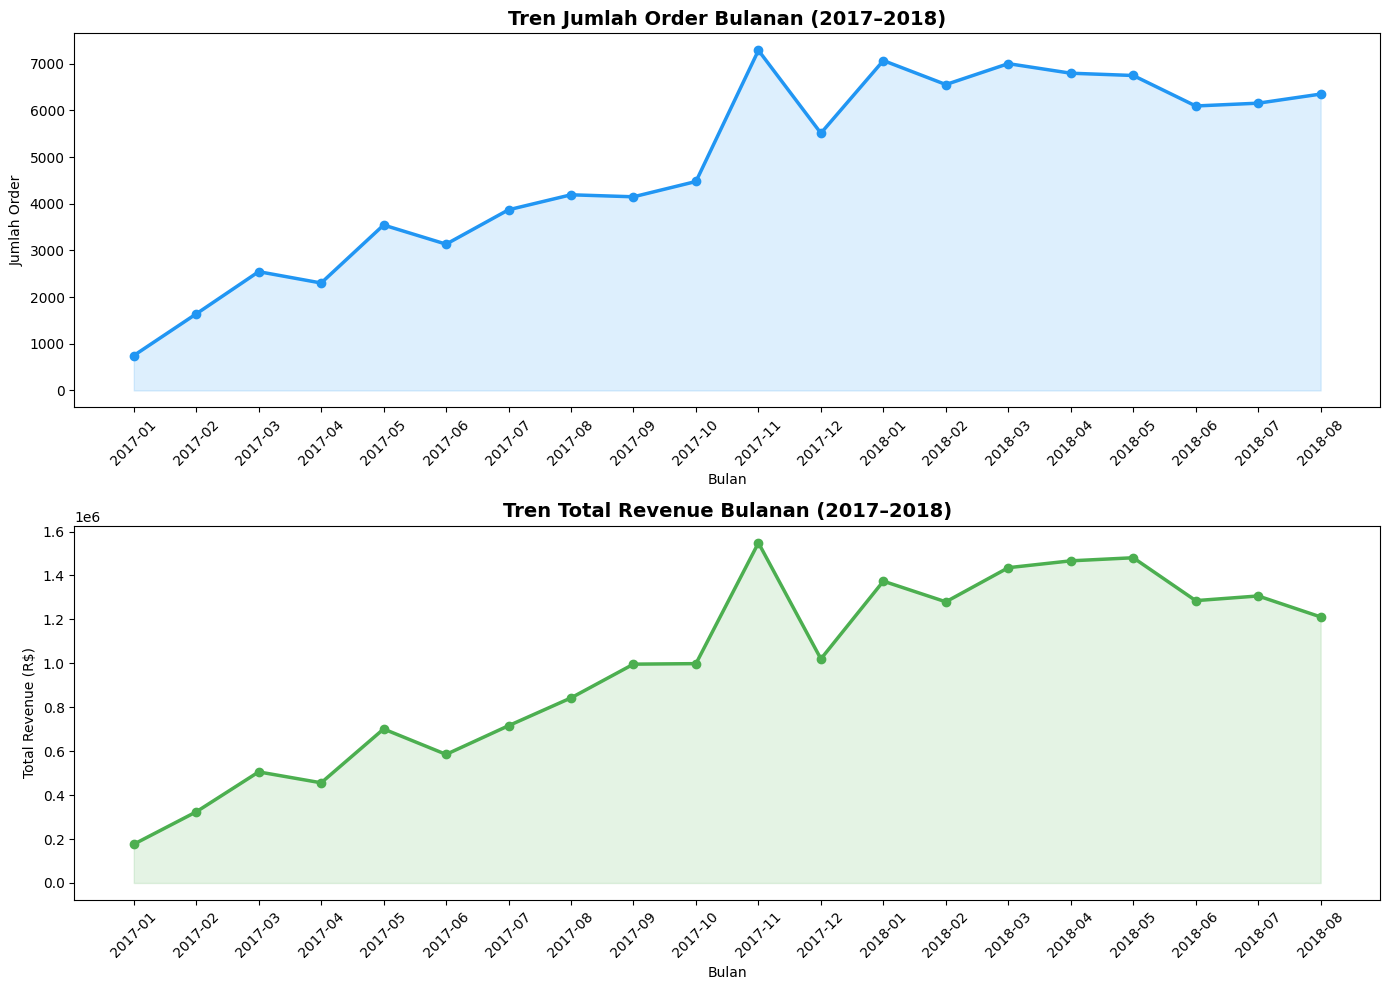

In [23]:
# ============================================================
# PERTANYAAN 1: Tren Penjualan Bulanan 2017-2018
# ============================================================

# Agregasi per bulan
monthly = (df_main.groupby('year_month', as_index=False)
    .agg(
        total_order   = ('order_id',      'nunique'),
        total_revenue = ('payment_value', 'sum')
    )
)
monthly['year_month_str'] = monthly['year_month'].astype(str)

# Visualisasi
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1 - Jumlah Order
axes[0].plot(monthly['year_month_str'], monthly['total_order'],
             marker='o', color='#2196F3', linewidth=2.5)
axes[0].fill_between(monthly['year_month_str'], monthly['total_order'],
                     alpha=0.15, color='#2196F3')
axes[0].set_title('Tren Jumlah Order Bulanan (2017–2018)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Jumlah Order')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2 - Total Revenue
axes[1].plot(monthly['year_month_str'], monthly['total_revenue'],
             marker='o', color='#4CAF50', linewidth=2.5)
axes[1].fill_between(monthly['year_month_str'], monthly['total_revenue'],
                     alpha=0.15, color='#4CAF50')
axes[1].set_title('Tren Total Revenue Bulanan (2017–2018)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Total Revenue (R$)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('tren_penjualan.png', bbox_inches='tight')
plt.show()

### Pertanyaan 2:

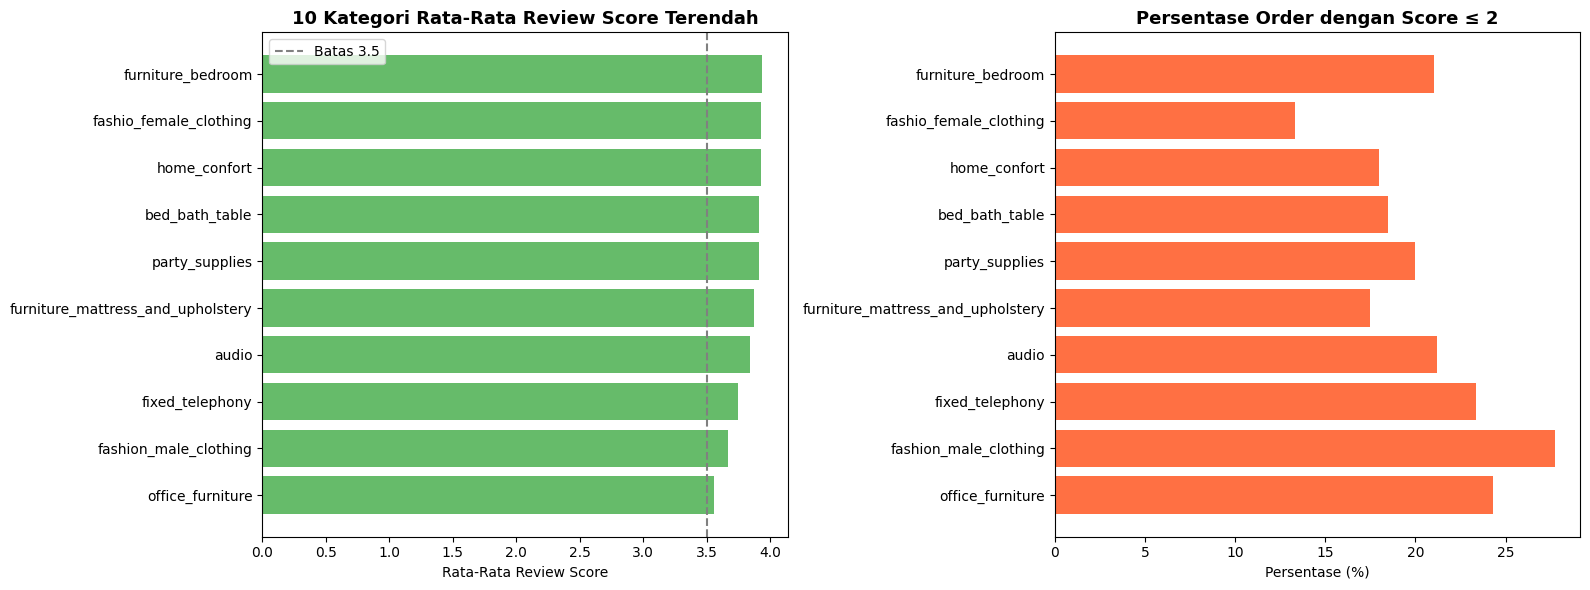

In [24]:
# ============================================================
# PERTANYAAN 2: Review Score per Kategori Produk
# ============================================================

# Merge reviews
df_review = df_main.merge(
    reviews_df[['order_id', 'review_score']], on='order_id', how='left'
)

# Agregasi per kategori
cat_review = (df_review
    .groupby('product_category_name_english', as_index=False)
    .agg(
        avg_score     = ('review_score', 'mean'),
        total_order   = ('order_id',     'nunique'),
        low_score_pct = ('review_score', lambda x: (x <= 2).sum() / len(x) * 100)
    )
)
cat_review = cat_review.dropna(subset=['product_category_name_english'])
cat_review = cat_review[cat_review['total_order'] >= 30].sort_values('avg_score')
bottom10   = cat_review.head(10)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Avg Score
colors = ['#ef5350' if s < 3.5 else '#66BB6A' for s in bottom10['avg_score']]
axes[0].barh(bottom10['product_category_name_english'], bottom10['avg_score'],
             color=colors)
axes[0].axvline(x=3.5, color='gray', linestyle='--', linewidth=1.5, label='Batas 3.5')
axes[0].set_title('10 Kategori Rata-Rata Review Score Terendah', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rata-Rata Review Score')
axes[0].legend()

# Plot 2 - % Low Score
axes[1].barh(bottom10['product_category_name_english'], bottom10['low_score_pct'],
             color='#FF7043')
axes[1].set_title('Persentase Order dengan Score ≤ 2', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Persentase (%)')

plt.tight_layout()
plt.savefig('review_kategori.png', bbox_inches='tight')
plt.show()

**Insight:** (Opsional)
- Tren order dan revenue menunjukkan pertumbuhan konsisten sepanjang 2017–2018 dengan puncak di November 2017 (Black Friday)
- Kategori office_furniture memiliki rata-rata review score
terendah, sementara fashion_male_clothing memiliki persentase
order dengan score ≤ 2 tertinggi (~28%). Hal ini mengindikasikan
adanya masalah kualitas produk atau ekspektasi pelanggan yang
tidak terpenuhi pada kedua kategori tersebut.

## Analisis Lanjutan (Opsional)

**PERTANYAAN 3: RFM ANALYSIS**

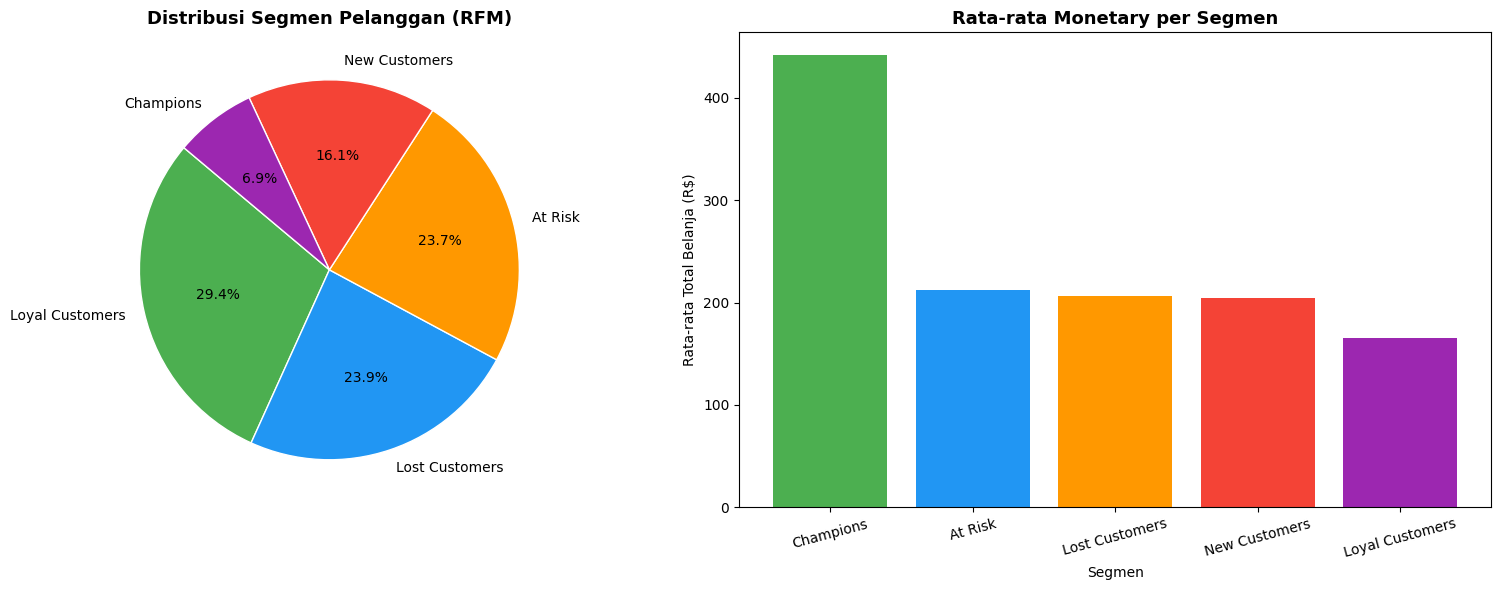

segment
Loyal Customers    27322
Lost Customers     22252
At Risk            22066
New Customers      14981
Champions           6462
Name: count, dtype: int64


In [25]:
# ============================================================
# PERTANYAAN 3: RFM ANALYSIS
# ============================================================

# Tanggal referensi = 1 hari setelah transaksi terakhir
snapshot_date = df_main['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Hitung RFM per pelanggan
rfm = (df_main.groupby('customer_unique_id', as_index=False)
    .agg(
        recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        frequency = ('order_id',                 'nunique'),
        monetary  = ('payment_value',            'sum')
    )
)

# Scoring RFM (1-5, 5 = terbaik)
rfm['r_score'] = pd.qcut(rfm['recency'],   5, labels=[5,4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'],  5, labels=[1,2,3,4,5])

rfm['rfm_score'] = (rfm['r_score'].astype(str) +
                    rfm['f_score'].astype(str) +
                    rfm['m_score'].astype(str))

# Segmentasi
def segment_rfm(row):
    r = int(row['r_score'])
    f = int(row['f_score'])
    m = int(row['m_score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['segment'] = rfm.apply(segment_rfm, axis=1)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Jumlah Pelanggan per Segmen
segment_count = rfm['segment'].value_counts()
colors = ['#4CAF50','#2196F3','#FF9800','#F44336','#9C27B0']
axes[0].pie(segment_count, labels=segment_count.index,
            autopct='%1.1f%%', colors=colors,
            startangle=140, wedgeprops={'edgecolor':'white'})
axes[0].set_title('Distribusi Segmen Pelanggan (RFM)', fontsize=13, fontweight='bold')

# Plot 2 - Rata-rata Monetary per Segmen
seg_monetary = rfm.groupby('segment')['monetary'].mean().sort_values(ascending=False)
axes[1].bar(seg_monetary.index, seg_monetary.values, color=colors)
axes[1].set_title('Rata-rata Monetary per Segmen', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Segmen')
axes[1].set_ylabel('Rata-rata Total Belanja (R$)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('rfm_analysis.png', bbox_inches='tight')
plt.show()

print(rfm['segment'].value_counts())

**PERTANYAAN 4: GEOSPATIAL ANALYSIS**

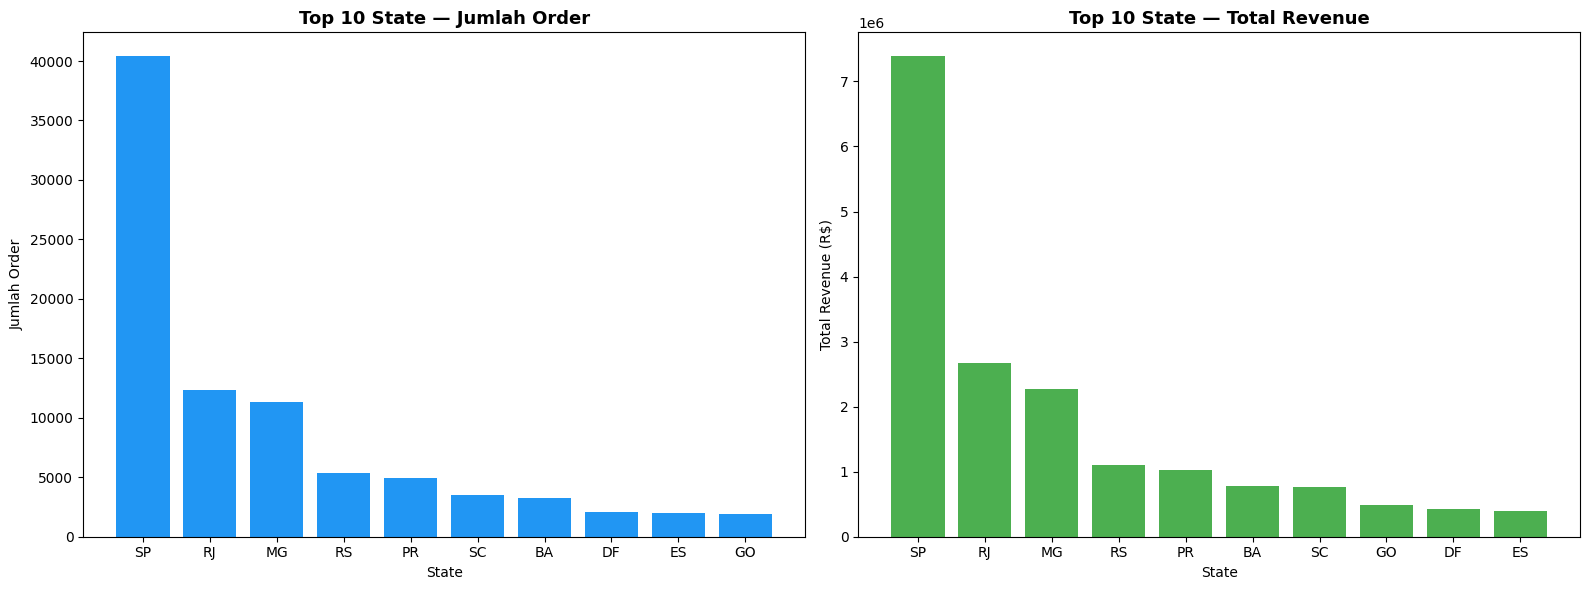

In [26]:
# ============================================================
# PERTANYAAN 4: GEOSPATIAL ANALYSIS
# ============================================================

# Agregasi order & revenue per state
state_stats = (df_main.groupby('customer_state', as_index=False)
    .agg(
        total_order   = ('order_id',      'nunique'),
        total_revenue = ('payment_value', 'sum')
    )
    .sort_values('total_order', ascending=False)
)

# Koordinat tiap state Brazil
state_coords = {
    'SP': (-23.55, -46.63), 'RJ': (-22.91, -43.17), 'MG': (-19.92, -43.93),
    'RS': (-30.03, -51.22), 'PR': (-25.43, -49.27), 'SC': (-27.60, -48.55),
    'BA': (-12.97, -38.50), 'GO': (-16.69, -49.26), 'ES': (-20.32, -40.31),
    'PE': (-8.05,  -34.88), 'CE': (-3.72,  -38.54), 'MT': (-15.60, -56.10),
    'MS': (-20.45, -54.63), 'DF': (-15.78, -47.93), 'PB': (-7.12,  -34.86),
    'MA': (-2.53,  -44.30), 'AM': (-3.10,  -60.03), 'RN': (-5.79,  -35.21),
    'AL': (-9.67,  -35.74), 'PI': (-5.09,  -42.80), 'PA': (-1.46,  -48.50),
    'SE': (-10.95, -37.07), 'RO': (-8.76,  -63.90), 'TO': (-10.25, -48.32),
    'AC': (-9.02,  -70.81), 'AP': (0.03,   -51.07), 'RR': (2.82,   -60.68)
}

state_stats['lat'] = state_stats['customer_state'].map(lambda x: state_coords.get(x, (0,0))[0])
state_stats['lng'] = state_stats['customer_state'].map(lambda x: state_coords.get(x, (0,0))[1])

# Peta Folium
m = folium.Map(location=[-15.0, -50.0], zoom_start=4, tiles='CartoDB positron')

for _, row in state_stats.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=row['total_order'] / state_stats['total_order'].max() * 40,
        color='#2196F3',
        fill=True,
        fill_color='#2196F3',
        fill_opacity=0.6,
        tooltip=f"{row['customer_state']}: {row['total_order']:,} orders | R$ {row['total_revenue']:,.0f}"
    ).add_to(m)

m.save('geospatial_brazil.html')
m

# Visualisasi Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 State by Order
top10_order = state_stats.head(10)
axes[0].bar(top10_order['customer_state'], top10_order['total_order'], color='#2196F3')
axes[0].set_title('Top 10 State — Jumlah Order', fontsize=13, fontweight='bold')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Jumlah Order')

# Top 10 State by Revenue
top10_rev = state_stats.sort_values('total_revenue', ascending=False).head(10)
axes[1].bar(top10_rev['customer_state'], top10_rev['total_revenue'], color='#4CAF50')
axes[1].set_title('Top 10 State — Total Revenue', fontsize=13, fontweight='bold')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Total Revenue (R$)')

plt.tight_layout()
plt.savefig('geospatial_bar.png', bbox_inches='tight')
plt.show()

**Insight:**
- Segmen Lost Customers dan At Risk mendominasi — artinya banyak pelanggan yang sudah tidak aktif dan perlu program retensi
- São Paulo (SP) mendominasi order & revenue secara nasional dengan kontribusi lebih dari 40%, sementara wilayah utara Brazil masih sangat minim transaksi

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Tren jumlah order dan revenue Olist menunjukkan pertumbuhan yang konsisten sepanjang 2017–2018. Penjualan mencapai puncaknya pada **November 2017** yang dipicu oleh event **Black Friday**, diikuti lonjakan serupa pada November 2018. Bulan-bulan akhir tahun (Oktober–Desember) secara konsisten menjadi periode penjualan tertinggi.

- **Conclusion pertanyaan 2:** Kategori office_furniture memiliki rata-rata review score
terendah, sementara fashion_male_clothing memiliki persentase
order dengan score ≤ 2 tertinggi (~28%). Hal ini mengindikasikan
adanya masalah kualitas produk atau ekspektasi pelanggan yang
tidak terpenuhi pada kedua kategori tersebut.

- **Conclusion Pertanyaan 3:** Hasil RFM Analysis menunjukkan sebagian besar pelanggan Olist termasuk segmen **Lost Customers** dan **At Risk**, artinya banyak pelanggan yang sudah lama tidak bertransaksi. Hanya sebagian kecil yang masuk kategori **Champions** (pelanggan dengan transaksi sering dan nilai tinggi).

- **Conclusion Pertanyaan 4:** State **São Paulo (SP)** mendominasi dengan kontribusi lebih dari 40% dari total order dan revenue secara nasional, diikuti **Rio de Janeiro (RJ)** dan **Minas Gerais (MG)**. Sementara wilayah utara Brazil seperti **Roraima (RR)** dan **Amapá (AP)** masih sangat minim transaksi.


**Rekomendasi Action Item:**
- Tim marketing harus mempersiapkan kampanye promo dan stok produk lebih awal sebelum **Oktober–November** setiap tahunnya untuk memaksimalkan momentum Black Friday.
- Tim quality control perlu melakukan **audit seller** di kategori electronics dan telephony serta memperketat standar produk yang boleh dijual di platform.
- Tim CRM harus membuat **program retensi** berupa voucher atau email reminder khusus untuk segmen **At Risk**, serta program loyalitas eksklusif untuk mempertahankan segmen **Champions**.
- Olist dapat memprioritaskan **ekspansi logistik dan kampanye pemasaran** di wilayah utara Brazil yang masih sangat potensial untuk dikembangkan.